# Introduction to `lamatrix`: Gradients of models

The gradients of best fit models are often extremely useful. In `lamatrix` it is possible to take any model and create the first gradient of that model. This is possible because each model type (e.g. polynomial, sinusoid, spline) can be mathematically written with its gradient. 

Let's look at that here

In [17]:
import numpy as np
from astropy.io import fits
import matplotlib.pyplot as plt
import sys

Here is a simple sinusoidal dataset

In [18]:
phi = np.arange(-np.pi, np.pi, 0.05)
y = 3.1293*np.sin(phi) + -4.294*np.cos(phi) + np.random.normal(0, 0.3, size=len(phi))
ye = np.ones(len(phi)) * 0.3

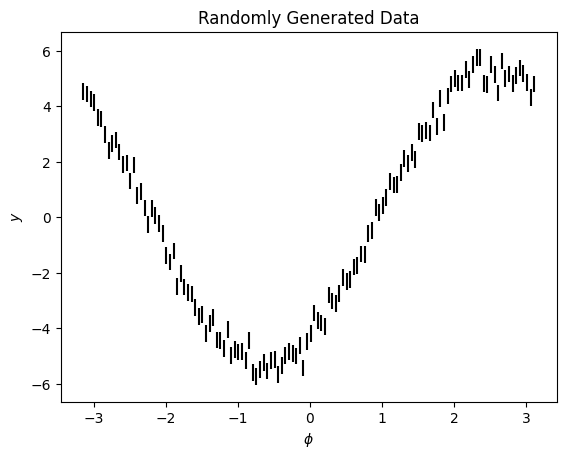

In [19]:
fig, ax = plt.subplots()
ax.errorbar(phi, y, ye, ls='', c='k')
ax.set(xlabel='$\phi$', ylabel='$y$', title='Randomly Generated Data');

We will fit it with a `Sinusoid` object

In [20]:
from lamatrix import Sinusoid

In [21]:
model = Sinusoid('phi')
model.latex_aliases['phi'] = "\phi"

Let's look at the equation for our model

In [22]:
model.equation

'\\[f(\\mathbf{\\phi}) = w_{0} \\sin(\\mathbf{\\phi}) + w_{1} \\cos(\\mathbf{\\phi})\\]'

We see this is a simple sinusoid. We're going to fit the weights $w$ to find the best fitting model. Let's do that fit

In [23]:
model.fit(phi=phi, data=y, errors=ye)

Now that we've fit the model we have posteriors

In [24]:
model.posteriors

DistributionContainer
	[(3.131, 0.038), (-4.333, 0.038)]

We can plot the model and see it fits well

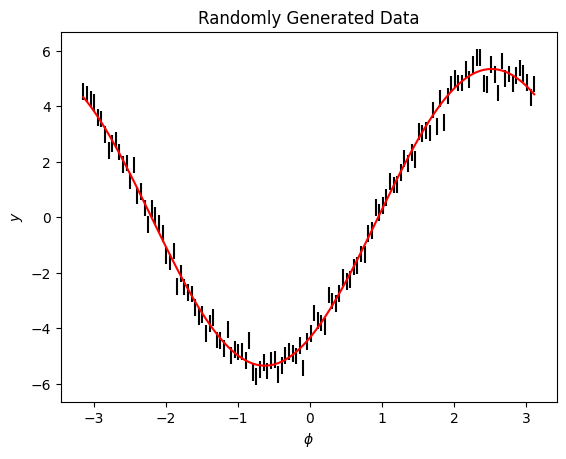

In [25]:
fig, ax = plt.subplots()
ax.errorbar(phi, y, ye, ls='', c='k')
ax.plot(phi, model.evaluate(phi=phi), c='r')
ax.set(xlabel='$\phi$', ylabel='$y$', title='Randomly Generated Data');

This fits the data well. Once we have this fit we may be interested in the gradient of the model. Given that we have fit our posteriors we can now take the gradient of the model

In [26]:
dmodel = model.to_gradient()
dmodel.latex_aliases['phi'] = "\phi"

In [27]:
dmodel

dSinusoid(phi)[n, 1]

This gradient only has a width of one. Let's look at the equations of the gradient of the model

In [28]:
dmodel.equation

'\\[f(\\mathbf{\\phi}) = w_{0} \\left({v}_{0}\\cos(\\mathbf{\\phi}) - {v}_{1}\\sin(\\mathbf{\\phi})\\right)\\]'

The equation for the gradient of the model has the best fit weights from the model, $v$ baked in. These are the posteriors from our previous step. We are now only able to find the weights for the gradient. In `lamatrix` we use the symbol $v$ by default to denote the best fit weights when they are baked into the model. 

In this case we have fixed $v$ to the best fit weights of the model. We can still find them in the gradient object by looking at the `weights` parameter

In [29]:
dmodel.weights

array([ 3.13081682, -4.3328903 ])

Let's plot the model and the gradient

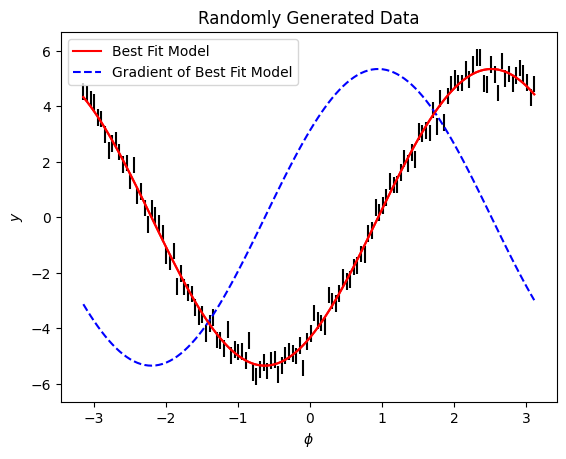

In [30]:
fig, ax = plt.subplots()
ax.errorbar(phi, y, ye, c='k', ls='')
ax.plot(phi, model.evaluate(phi=phi), c='r', label='Best Fit Model')
ax.plot(phi, dmodel.design_matrix(phi=phi)[:, 0], c='b', ls='--', label='Gradient of Best Fit Model')
ax.plot(phi, model.evaluate(phi=phi), c='r')
ax.legend()
ax.set(xlabel='$\phi$', ylabel='$y$', title='Randomly Generated Data');

The `dmodel` object enables you to fit the amplitude of the gradient ($v$) using `lamatrix` to any dataset. This can be useful when you are looking for small translations across large datasets. Let's look at an example.

We'll make a 2D dataset

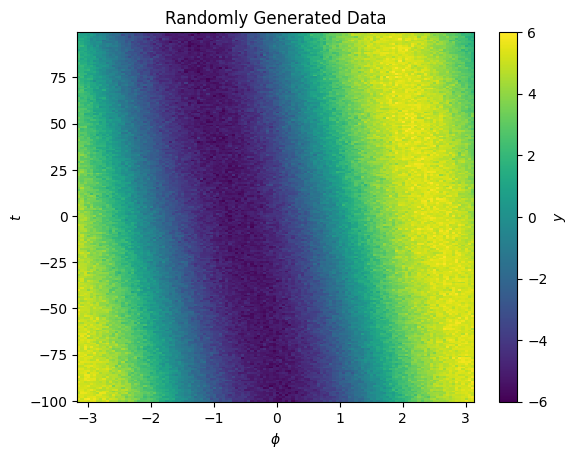

In [31]:
t = np.arange(-100, 100, 1)
phi = np.arange(-np.pi, np.pi, 0.05)[:, None] * np.ones(t.shape[0])
t = t[None, :] * np.ones(phi.shape)
dphi =  t * 0.007
y = 3.1293*np.sin(phi + dphi) + -4.294*np.cos(phi + dphi) + np.random.normal(0, 0.3, size=phi.shape)
ye = np.ones(phi.shape) * 0.3

fig, ax = plt.subplots()
im = ax.pcolormesh(phi.mean(axis=1), t.mean(axis=0), y.T, vmin=-6, vmax=6)
ax.set(xlabel='$\phi$', ylabel='$t$', title='Randomly Generated Data');
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("$y$")

Now we have y as a function of both $\phi$ and another variable $t$. There is a small shift in the center of the signal as a function of $t$.

We can start by assuming out data is a function of $\phi$ only, and retrieve a fit

In [32]:
model = Sinusoid('phi')
model.latex_aliases['phi'] = "\phi"
model.fit(phi=phi, data=y, errors=ye)

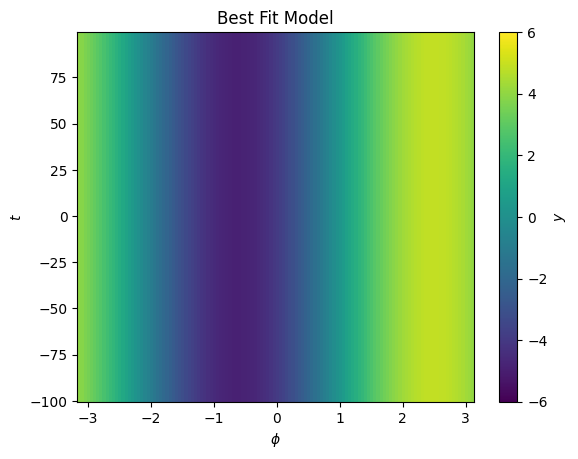

In [33]:
fig, ax = plt.subplots()
im = ax.pcolormesh(phi.mean(axis=1), t.mean(axis=0), model.evaluate(phi=phi).T, vmin=-6, vmax=6)
ax.set(xlabel='$\phi$', ylabel='$t$', title='Best Fit Model');
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("$y$")

This looks like a good fit, but we can not model our shift as a function of $t$

In [34]:
dmodel = model.to_gradient()
dmodel.latex_aliases['phi'] = "\phi"

In [36]:
from lamatrix import Polynomial

In [37]:
updated_model = model + (dmodel * Polynomial("t", order=1))
updated_model.latex_aliases['phi'] = "\phi"

Now our model is the original sinusoid, plus a polynomial in the gradient of that model with respect to $\phi$ multiplied by a polynomial in $t$. Our inital model fit the to the average of all data across $t$, now we use the same model and allow for some small flexibility as a function of $t$

In [38]:
updated_model

JointModel
	Sinusoid(phi)[n, 2]
	CrosstermModel(phi, t)[n, 1]

In [39]:
updated_model.equation

'\\[f(\\mathbf{\\phi}, \\mathbf{t}) = w_{0} \\sin(\\mathbf{\\phi}) + w_{1} \\cos(\\mathbf{\\phi}) + w_{2} \\left({v}_{0}\\cos(\\mathbf{\\phi}) - {v}_{1}\\sin(\\mathbf{\\phi})\\right)\\mathbf{t}^{1}\\]'

Now we're fitting our three weights $w$ to find the best fit. Let's fit this model

In [40]:
updated_model.fit(phi=phi, t=t, data=y, errors=ye)

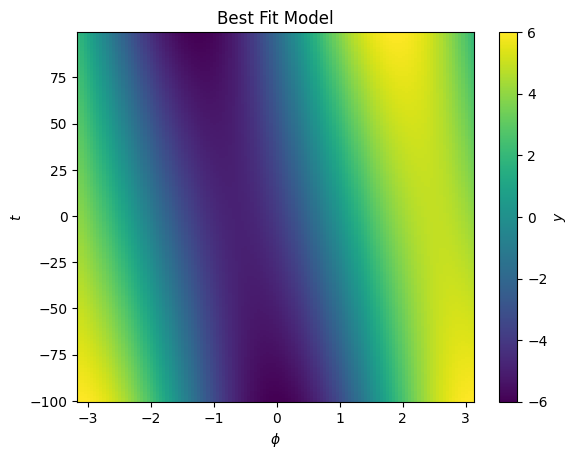

In [41]:
fig, ax = plt.subplots()
im = ax.pcolormesh(phi.mean(axis=1), t.mean(axis=0), updated_model.evaluate(phi=phi, t=t).T, vmin=-6, vmax=6)
ax.set(xlabel='$\phi$', ylabel='$t$', title='Best Fit Model');
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("$y$")

We see now the best fit is with a significant component in $t$. 

This model fit is **an approximation**. In truth we should be updating our grid $\phi$ since we know there is a drift in the signal over time. 

Let's look at the best fit shift model

In [44]:
updated_model[1].posteriors[0]

(0.0072361, 9.5e-06)

In [51]:
best_fit_shift = Polynomial('t', order=1, posteriors=updated_model[1].posteriors)

We see this is capturing the trend in the grid. Let's update our model for $\phi$

In [56]:
updated_phi = phi + best_fit_shift.evaluate(t=t)

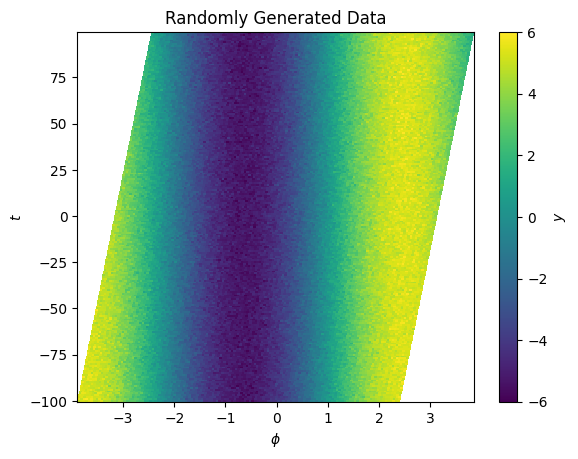

In [60]:
fig, ax = plt.subplots()
im = ax.pcolormesh(updated_phi.T, t.T, y.T, vmin=-6, vmax=6)
ax.set(xlabel='$\phi$', ylabel='$t$', title='Randomly Generated Data');
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("$y$")

We're now able to update $\phi$ to remove the shift. We can repeat the process above now on our updated $\phi$ grid to continue to refine the model and position. 

We're able to do something similar to this using the `Spline` object. Let's make a set of synthetic spectra as a function of $x$ with a small shift as a function of position in $y$

In [185]:
x = np.arange(-5, 5, 0.01)
y = np.arange(-1, 1, 0.01)
X, Y = np.meshgrid(x, y)

z = np.random.normal(size=len(x))
z = np.convolve(z, np.ones(300), mode='same')

spectra = np.interp(x - (0.07*y)[:, None], x, z)

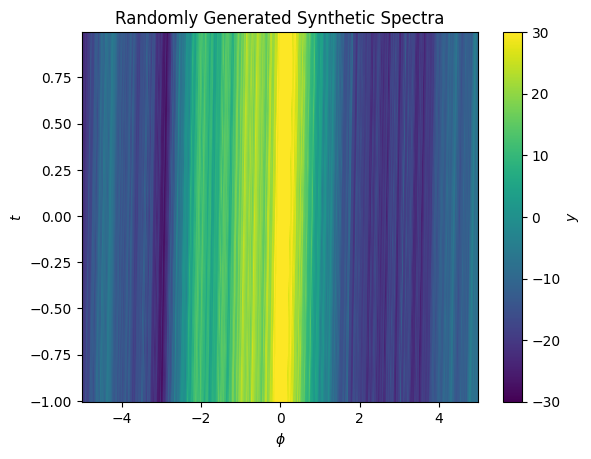

In [186]:
fig, ax = plt.subplots()
im = ax.pcolormesh(x, y, spectra, vmin=-30, vmax=30)
ax.set(xlabel='$\phi$', ylabel='$t$', title='Randomly Generated Synthetic Spectra');
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("$y$")

These spectra have lots of fine bumps, and a very small shift as a function of $y$. Let's apply our above procedure to find an approximation of the shift.

In [187]:
from lamatrix import Spline

In [188]:
knot_spacing = 0.05
order = 3
knots = np.arange(-5 - knot_spacing * (order - 1), 5 + (knot_spacing * (order - 1)) + knot_spacing, knot_spacing)

In [189]:
spline = Spline('x', knots=knots, order=order)

In [190]:
spline.fit(x=x, data=spectra.mean(axis=0))

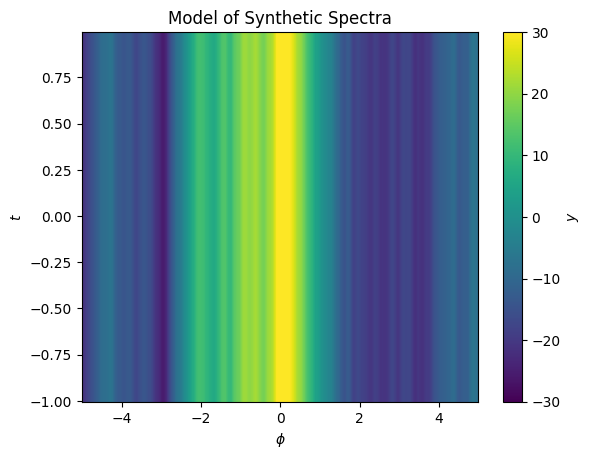

In [191]:
fig, ax = plt.subplots()
im = ax.pcolormesh(x, y, spline.evaluate(x=X), vmin=-30, vmax=30)
ax.set(xlabel='$\phi$', ylabel='$t$', title='Model of Synthetic Spectra');
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("$y$")

Here we've fit our model to the mean of the data in $y$. Now we can calculate the gradient of the model with respect to $x$.

In [192]:
dspline = spline.to_gradient()

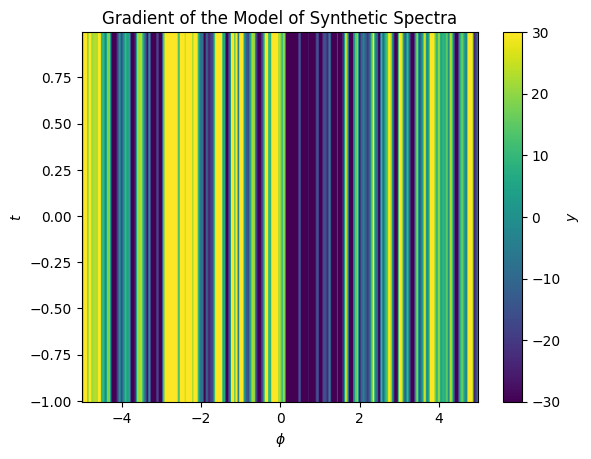

In [193]:
fig, ax = plt.subplots()
im = ax.pcolormesh(x, y, dspline.design_matrix(x=X).dot([1]), vmin=-30, vmax=30)
ax.set(xlabel='$\phi$', ylabel='$t$', title='Gradient of the Model of Synthetic Spectra');
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("$y$")


Now to capture the shift we need a model for the shift as a function of $y$. We'll pick a simple polynomial with an order of 1. 

In [194]:
model = spline + (Polynomial('y', order=1) * dspline)

In [195]:
model

JointModel
	Spline(x)[n, 202]
	CrosstermModel(x, y)[n, 1]

In [196]:
model.fit(x=X, y=Y, data=spectra)

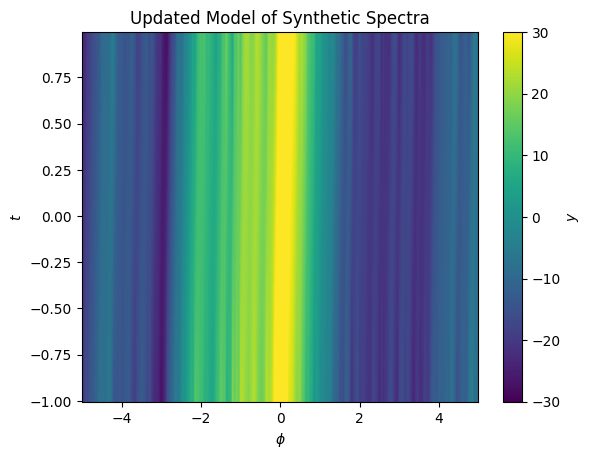

In [198]:
fig, ax = plt.subplots()
im = ax.pcolormesh(x, y, model.evaluate(x=X, y=Y), vmin=-30, vmax=30)
ax.set(xlabel='$\phi$', ylabel='$t$', title='Updated Model of Synthetic Spectra');
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("$y$")

Now our model captures a small shift in the spectrum position as a function of $y$. We can look at the residuals and see they are small.

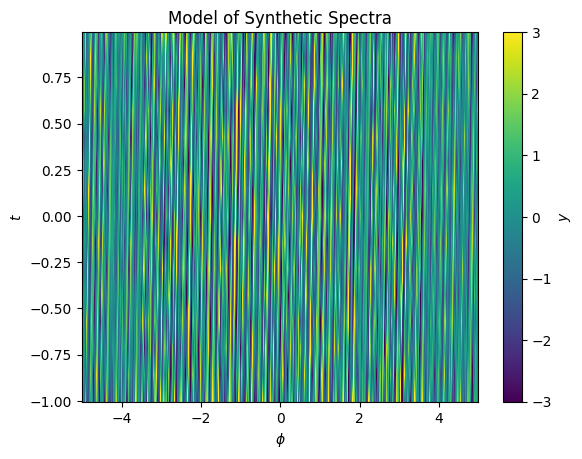

In [199]:
fig, ax = plt.subplots()
im = ax.pcolormesh(x, y, spectra - model.evaluate(x=X, y=Y), vmin=-3, vmax=3)
ax.set(xlabel='$\phi$', ylabel='$t$', title='Model of Synthetic Spectra');
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("$y$")

We can use this to build a model of the displacement in $x$ as a function of $y$

In [200]:
dX = Polynomial('y', order=1, posteriors=model[1].posteriors).evaluate(y=Y)

This can be used to translate our data to remove the shift

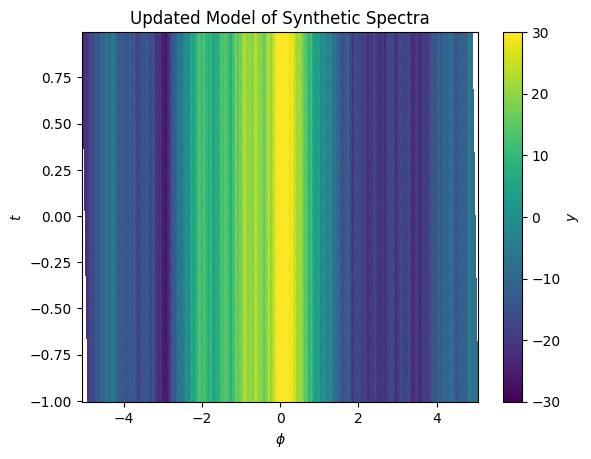

In [201]:
fig, ax = plt.subplots()
im = ax.pcolormesh(X.T + dX.T, Y.T, spectra.T, vmin=-30, vmax=30)
ax.set(xlabel='$\phi$', ylabel='$t$', title='Updated Model of Synthetic Spectra');
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("$y$")

We can iterate this procedure, updating the model when fitting on this new registered grid, and refine the shift model

In [202]:
spline.fit(x=X + dX, data=spectra)
model = spline + (Polynomial('y', order=1) * dspline)
model.fit(x=X + dX, y=Y, data=spectra)

When we evaluate the residuals again after iterating, we see they are even smaller

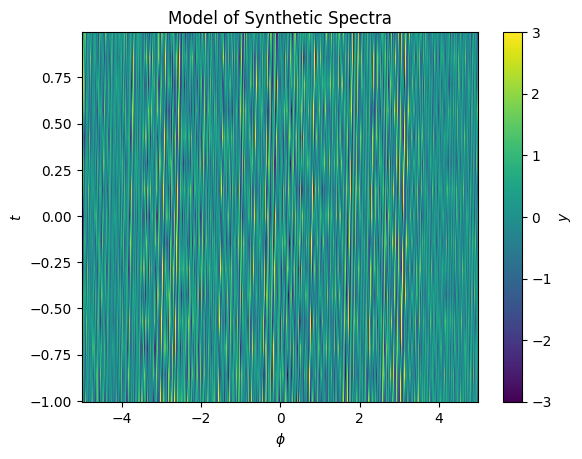

In [208]:
fig, ax = plt.subplots()
im = ax.pcolormesh(X.T, Y.T, (spectra - model.evaluate(x=X + dX, y=Y)).T, vmin=-3, vmax=3)
ax.set(xlabel='$\phi$', ylabel='$t$', title='Model of Synthetic Spectra');
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("$y$")

To sum up, the gradients of models are available in `lamatrix` in order to enable users to, for example, fit small shifts in models as a function of other dimensions, and to better understand where the rate of change of the best fit model is highest.